# Gems Finder — Sound Hunters

**Residência em IA · UnB — Turma 2 · Grupo 9 · Nano-Challenge: Spotify Data**

**Integrantes**

- Amanda Elisa de Oliveira Carvalho
- Arthur de Melo Garcia
- Maria Carolina Martins Frota
- Samara Letícia Alves dos Santos
- Wingrid da Costa Silva

Sistema de recomendação de **joias escondidas**: descobrir músicas parecidas
com o que você gosta, de **artistas pouco conhecidos**.

Metodologia registrada em
[`docs/specs/2026-09-01-recommender-methodology/spec.md`](../docs/specs/2026-09-01-recommender-methodology/spec.md).

**Roda localmente** — o dataset está no repositório, sem Colab e sem Drive.

## A dor do mercado

Playlists caem nas mesmas bolhas algorítmicas e recomendam só os artistas mais
famosos. Playlists de humor (foco, treino, relaxamento) repetem as faixas
óbvias e ignoram milhares de artistas talentosos escondidos no catálogo.
Artistas independentes permanecem invisíveis porque a baixa popularidade os
exclui da própria descoberta — um ciclo fechado.

## Ordem do trabalho

1. Carga e limpeza (incluindo a **deduplicação real** por `track_id`)
2. Normalização — e por que **MinMax** e não `StandardScaler` nesta etapa
3. Correlação de Pearson
4. **Seleção de features** com as 7 Common Filter Techniques, categóricos incluídos
5. Clusterização em moods com as features selecionadas
6. Status do artista (Consolidado × Independente) — e por que `max`, não média
7. Motor de recomendação e exportação dos artefatos para o `app.py`

## 0. Dicionário de dados

O que cada coluna significa. Está aqui porque a interpretação de duas delas
(`speechiness` e `instrumentalness`) muda decisões adiante.

### Identificação e metadados

| Coluna | Significado |
|---|---|
| `track_id` | ID único da faixa no Spotify |
| `artists` | Nome do(s) artista(s), separados por `;` quando há mais de um |
| `album_name` | Nome do álbum |
| `track_name` | Nome da música |
| `track_genre` | Gênero musical da faixa (114 valores: acoustic, afrobeat, alt-rock, ambient, anime, …) |
| `popularity` | Índice de popularidade, de 0 a 100 |
| `duration_ms` | Duração em milissegundos |
| `explicit` | Booleano: a faixa tem conteúdo explícito |

### Atributos de áudio

| Coluna | Significado |
|---|---|
| `danceability` | Quão dançável é a faixa, a partir de tempo, estabilidade de ritmo e força da batida |
| `energy` | Medida perceptual de intensidade e atividade — faixas enérgicas soam rápidas, barulhentas e cheias |
| `key` | Tonalidade musical |
| `loudness` | Sonoridade geral em decibéis (dB) — valores negativos |
| `mode` | Modalidade: maior = 1, menor = 0 |
| `speechiness` | **Presença de palavras faladas** na faixa |
| `acousticness` | Confiança de que a faixa é acústica |
| `instrumentalness` | Predição de que a faixa **não contém vocais** |
| `liveness` | Presença de público na gravação (indica gravação ao vivo) |
| `valence` | Positividade musical — alta soa alegre/eufórica, baixa soa triste/raivosa |
| `tempo` | Batidas por minuto (BPM) |
| `time_signature` | Compasso estimado |

### As duas escalas que exigem cuidado

**`speechiness` tem faixas de leitura definidas**, e ignorá-las leva a
conclusão errada:

| Valor | Leitura |
|---|---|
| **> 0,66** | Faixa inteiramente falada — podcast, audiolivro, comédia |
| **0,33 – 0,66** | Mistura de música e fala, incluindo **rap** |
| **< 0,33** | Música, sem fala predominante |

Um valor médio de 0,50 **não** significa "gente falando": está na banda do rap
e da fala misturada. Voltamos a isso na seção 6.

**`instrumentalness` é o inverso do que o nome sugere ao olho apressado:**
valor **alto** significa **ausência de vocais**. É essa coluna que separa dois
moods acústicos que, sem ela, pareceriam o mesmo grupo.

## 1. Carga dos dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

CANDIDATOS = [Path("../data/raw/dataset_spotify_raw.csv"),
              Path("data/raw/dataset_spotify_raw.csv")]
CAMINHO = next((c for c in CANDIDATOS if c.exists()), None)
if CAMINHO is None:
    from google.colab import drive          # fallback para quem usa Colab
    drive.mount("/content/drive")
    CAMINHO = Path("/content/drive/MyDrive/dataset(in).csv")

bruto = pd.read_csv(CAMINHO)
print(f"Carregado de: {CAMINHO}")
print(f"{len(bruto):,} linhas · {len(bruto.columns)} colunas")
bruto.head()

Carregado de: ..\data\raw\dataset_spotify_raw.csv
114,000 linhas · 21 colunas


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Limpeza

Três passos, nesta ordem: coluna de índice, linhas idênticas, linha nula.

In [2]:
df = bruto.drop(columns=["Unnamed: 0"])          # era só o índice salvo no CSV

antes = len(df)
df = df.drop_duplicates(keep="first")
print(f"linhas idênticas removidas: {antes - len(df):,}")

nulos = df.isnull().sum()
print("\nnulos por coluna (só as que têm):")
print(nulos[nulos > 0].to_string())

df = df[df["artists"].notna()]
print(f"\napós limpeza: {len(df):,} linhas")

linhas idênticas removidas: 450

nulos por coluna (só as que têm):
artists       1
album_name    1
track_name    1

após limpeza: 113,549 linhas


### 2.1 A deduplicação que faltava

`drop_duplicates(keep='first')` removeu pouquíssimas linhas. O motivo é que
**a mesma faixa aparece uma vez por gênero a que pertence** — e essas linhas
não são idênticas, porque `track_genre` difere. Sobram milhares de `track_id`
repetidos.

Isso importa por dois motivos:

- **Na clusterização:** uma faixa em 6 gêneros entra 6 vezes no K-Means e puxa
  os centroides.
- **No cruzamento com as faixas do usuário:** um `merge` por `track_id` com
  duplicatas multiplica linhas e distorce o perfil.

Antes de deduplicar, vamos verificar **o que difere** entre as linhas
repetidas — se os atributos de áudio divergissem, seria erro de dados.

In [3]:
print(f"track_id duplicados: {df['track_id'].duplicated().sum():,}")

g = df.groupby("track_id")
COLUNAS = ["danceability", "energy", "valence", "acousticness", "speechiness",
           "instrumentalness", "liveness", "loudness", "tempo", "duration_ms",
           "key", "mode", "time_signature", "explicit", "popularity",
           "track_name", "artists"]
print("\ncolunas que divergem entre linhas do mesmo track_id:")
for col in COLUNAS:
    divergentes = (g[col].nunique(dropna=False) > 1).sum()
    if divergentes:
        print(f"  {col:18} {divergentes:>6,} faixas  <-- DIVERGE")
print("  (as não listadas são idênticas em todas as repetições)")

track_id duplicados: 23,809

colunas que divergem entre linhas do mesmo track_id:


  popularity            720 faixas  <-- DIVERGE
  (as não listadas são idênticas em todas as repetições)


**Resultado:** todos os atributos de áudio são idênticos — a duplicação carrega
apenas o gênero. A única exceção é `popularity`.

Vamos olhar o tamanho dessa divergência, porque ±1 é ruído de coleta e ±40 é
decisão de projeto.

In [4]:
amp = (g["popularity"].max() - g["popularity"].min())
div = amp[amp > 0]
print(f"faixas com popularity divergente: {len(div):,}")
print(f"  divergência de exatamente 1: {(div == 1).sum():,} ({(div == 1).mean()*100:.0f}%)")
print(f"  divergência maior que 10   : {(div > 10).sum():,}")

print("\npiores casos:")
for tid, a in div.nlargest(5).items():
    r = df[df.track_id == tid]
    print(f"  amplitude={a:>3}  valores={sorted(r.popularity.tolist())}  "
          f"{str(r.iloc[0].artists)[:22]} - {str(r.iloc[0].track_name)[:28]}")

faixas com popularity divergente: 720
  divergência de exatamente 1: 673 (93%)
  divergência maior que 10   : 13

piores casos:
  amplitude= 44  valores=[0, 0, 44]  Arctic Monkeys - Sculptures Of Anything Goes
  amplitude= 42  valores=[0, 0, 42]  Arctic Monkeys - The Car
  amplitude= 42  valores=[0, 0, 42]  Arctic Monkeys - I Ain’t Quite Where I Think 
  amplitude= 41  valores=[0, 0, 41]  Arctic Monkeys - There’d Better Be A Mirrorba
  amplitude= 41  valores=[0, 0, 41]  Arctic Monkeys - Big Ideas


Os piores casos têm padrão: valores como `[0, 0, 44]`. Zero aqui significa
**não capturado**, não "sem streams" — são faixas de álbuns conhecidos.

Por isso agregamos `popularity` com **`max`**. Com `keep='first'` essas faixas
ficariam registradas como 0 e a regra de piso (adiante) as classificaria como
ruído sem streams, o que é falso.

**A deduplicação correta**, então: uma linha por `track_id`, áudio de qualquer
repetição (são idênticas), `popularity` por `max`, e o gênero preservado como
**lista** em vez de descartado.

In [5]:
generos = df.groupby("track_id")["track_genre"].apply(lambda s: sorted(set(s)))
pop_max = df.groupby("track_id")["popularity"].max()

faixas = df.drop_duplicates(subset="track_id").set_index("track_id").copy()
faixas["generos"] = generos
faixas["n_generos"] = generos.str.len()
faixas["popularity"] = pop_max
faixas = faixas.drop(columns=["track_genre"])

# Tabela longa (faixa, gênero) para as análises por gênero — nada se perde.
faixa_genero = (generos.explode().reset_index()
                .rename(columns={"track_genre": "genero"}))

print(f"faixas únicas: {len(faixas):,}")
print(f"pares (faixa, gênero): {len(faixa_genero):,}")
print(f"gêneros por faixa — média {faixas.n_generos.mean():.2f}, máximo {faixas.n_generos.max()}")
print("\ndistribuição:")
print(faixas.n_generos.value_counts().sort_index().to_string())

faixas únicas: 89,740
pares (faixa, gênero): 113,549
gêneros por faixa — média 1.27, máximo 9

distribuição:
n_generos
1    73441
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1


In [6]:
# A faixa mais multi-gênero do catálogo, como sanidade
i = faixas.n_generos.idxmax()
r = faixas.loc[i]
print(f"{r.artists} - {r.track_name}")
print(f"  {r.n_generos} gêneros: {', '.join(r.generos)}")

Badfinger - Baby Blue - Remastered 2010
  9 gêneros: blues, country, folk, j-pop, j-rock, power-pop, psych-rock, singer-songwriter, songwriter


## 2.2 O catálogo tem conteúdo que não é música

Antes de clusterizar, vale checar se o dataset tem faixas faladas — podcast,
stand-up, audiolivro. Elas atrapalhariam tanto os clusters quanto as
recomendações.

O caminho óbvio é filtrar por `speechiness > 0,66`, a banda "inteiramente
falada". Vamos testar se esse é o critério certo, olhando as faixas de fato.

In [7]:
falado = faixas[faixas.speechiness > .66]
print(f"faixas com speechiness > 0,66: {len(falado):,} ({len(falado)/len(faixas)*100:.2f}% do catálogo)")
print(f"  duração média: {falado.duration_ms.mean()/60000:.1f} min "
      f"(catálogo: {faixas.duration_ms.mean()/60000:.1f} min)")
print(f"  popularidade média: {falado.popularity.mean():.1f} "
      f"(catálogo: {faixas.popularity.mean():.1f})")
print("\ngêneros:")
print(pd.Series([g for l in falado.generos for g in l]).value_counts().head(8).to_string())

faixas com speechiness > 0,66: 868 (0.97% do catálogo)
  duração média: 3.7 min (catálogo: 3.8 min)
  popularidade média: 23.7 (catálogo: 33.2)

gêneros:
comedy        764
kids           11
children       10
show-tunes     10
funk            9
jazz            5
chill           4
j-dance         4


In [8]:
print("=== as mais faladas (speechiness > 0,90) — é stand-up ===")
for _, r in falado.nlargest(10, "speechiness").iterrows():
    print(f"  sp={r.speechiness:.2f} {r.duration_ms/60000:5.1f}min  "
          f"{str(r.artists)[:22]:22} | {str(r.track_name)[:42]}")

print("\n=== a fronteira (0,66-0,75) — e aqui é MÚSICA ===")
borda = falado[(falado.speechiness >= .66) & (falado.speechiness < .75)]
for _, r in borda.nlargest(10, "popularity").iterrows():
    print(f"  sp={r.speechiness:.2f} pop={r.popularity:>3}  "
          f"{str(r.artists)[:20]:20} | {str(r.track_name)[:34]:34} [{','.join(r.generos[:2])}]")

=== as mais faladas (speechiness > 0,90) — é stand-up ===
  sp=0.96   0.7min  Tenacious D            | turd whistle
  sp=0.96   1.1min  Tom Papa               | The Real World
  sp=0.96   3.5min  Patton Oswalt          | Less and Less Radical
  sp=0.96   3.2min  Dan Cummins            | Get Rid of That Joke!
  sp=0.96   3.4min  Patton Oswalt          | Parents and Pills
  sp=0.96   2.2min  Robert Schimmel        | Chemotherapy
  sp=0.96   5.7min  Tom Papa               | The Human Contract
  sp=0.96   2.3min  Tom Papa               | Angry Young Men
  sp=0.96   3.6min  Tom Papa               | Morning Tom
  sp=0.96   1.1min  Robert Schimmel        | Non Hogkins Lymphoma

=== a fronteira (0,66-0,75) — e aqui é MÚSICA ===
  sp=0.72 pop= 76  Fresh                | Chop (Nouvelle École)              [french]
  sp=0.72 pop= 73  Arz                  | Alone With You                     [chill]
  sp=0.70 pop= 67  22Gz                 | Suburban, Pt. 2                    [r-n-b]
  sp=0.72 pop=

**Nenhum dos dois critérios isolados serve.** Acima de 0,90 é stand-up
inequívoco, mas a banda 0,66–0,75 tem música real e popular — rap francês,
drill e bastante **funk brasileiro**, que tem entrega vocal densa por natureza.

E o gênero sozinho é pior ainda. Vamos testar as três regras possíveis.

In [9]:
GENEROS_NAO_MUSICAIS = {"comedy", "children", "kids", "show-tunes"}
em_genero_nm = faixas.generos.apply(lambda l: bool(GENEROS_NAO_MUSICAIS & set(l)))
muito_falado = faixas.speechiness > .66

regras = {
    "A) só gênero":                     em_genero_nm,
    "B) só speechiness > 0,66":         muito_falado,
    "C) gênero E speechiness > 0,66":   em_genero_nm & muito_falado,
}
print(f"{'regra':34} {'remove':>8} {'pop. média':>11}")
print("-" * 56)
for nome, m in regras.items():
    print(f"{nome:34} {m.sum():>8,} {faixas[m].popularity.mean():>11.1f}")

print(f"\nA remove {(em_genero_nm & ~muito_falado).sum():,} faixas destes gêneros que NÃO são faladas")
print(f"B remove {(muito_falado & ~em_genero_nm).sum():,} faixas faladas que NÃO são destes gêneros")

regra                                remove  pop. média
--------------------------------------------------------
A) só gênero                          3,979        26.5
B) só speechiness > 0,66                868        23.7
C) gênero E speechiness > 0,66          795        22.9

A remove 3,184 faixas destes gêneros que NÃO são faladas
B remove 73 faixas faladas que NÃO são destes gêneros


In [10]:
# O teste que decide: o que a regra A removeria a mais? E musica?
print("=== faixas de comedy/kids/show-tunes com speechiness BAIXO ===")
baixo = faixas[em_genero_nm & ~muito_falado]
print(f"{len(baixo):,} faixas | speechiness médio {baixo.speechiness.mean():.3f}")
print("\nas mais populares:")
for _, r in baixo.nlargest(12, "popularity").iterrows():
    print(f"  sp={r.speechiness:.2f} pop={r.popularity:>3}  {str(r.artists)[:22]:22} "
          f"| {str(r.track_name)[:36]:36} [{','.join(r.generos[:2])}]")

=== faixas de comedy/kids/show-tunes com speechiness BAIXO ===
3,184 faixas | speechiness médio 0.119

as mais populares:
  sp=0.11 pop= 77  Pinkfong               | Baby Shark                           [children]
  sp=0.31 pop= 75  Jon Lajoie             | Everyday Normal Guy 2                [comedy]
  sp=0.03 pop= 75  Loren Allred           | Never Enough                         [show-tunes]
  sp=0.03 pop= 75  Idina Menzel           | Let It Go - From "Frozen"/Soundtrack [show-tunes]
  sp=0.38 pop= 74  Afroman                | Crazy Rap (Colt 45 & 2 Zig Zags)     [comedy]
  sp=0.04 pop= 74  Zac Efron;Zendaya      | Rewrite The Stars                    [show-tunes]
  sp=0.04 pop= 74  Zac Efron;Zendaya      | Rewrite The Stars                    [show-tunes]
  sp=0.06 pop= 74  Ziv Zaifman;Hugh Jackm | A Million Dreams                     [show-tunes]
  sp=0.19 pop= 74  Keala Settle;The Great | This Is Me                           [show-tunes]
  sp=0.04 pop= 73  Idina Menzel;AURORA    

**Isso decide a questão.** As faixas que a regra A removeria a mais são
**Baby Shark**, **Let It Go**, **Never Enough**, **A Million Dreams**,
**Hakuna Matata**, **Wheels on the Bus**, e as canções do Tenacious D — que é
uma banda **musical** de comédia. É tudo música, e uma delas está na
popularidade 77.

Filtrar por gênero deletaria centenas de canções legítimas só porque o álbum é
catalogado como comédia ou infantil.

**Decisão: regra C — gênero E `speechiness > 0,66`.** Ela é precisa nos dois
eixos: não remove música de fora desses gêneros (o que B fazia), nem canção de
dentro deles (o que A fazia). Remove exatamente o conteúdo que é, ao mesmo
tempo, catalogado como não-musical e efetivamente falado.

### E se usássemos também a duração?

Hipótese razoável: podcast e stand-up são mais longos que música, então a
duração ajudaria a separá-los. Vale testar antes de aceitar.

In [11]:
faixas["minutos"] = faixas.duration_ms / 60000
falado_C = em_genero_nm & muito_falado

print("=== duração: falado (regra C) vs resto do catálogo ===")
for nome, m in [("falado", falado_C), ("música", ~falado_C)]:
    s = faixas.loc[m, "minutos"]
    print(f"  {nome:8} n={m.sum():>6,}  média {s.mean():.2f} min  "
          f"mediana {s.median():.2f}  p90 {s.quantile(.9):.2f}  máx {s.max():.1f}")

print("\n=== quantos falados são longos? ===")
for lim in (5, 6, 8, 10, 15):
    n = (faixas.loc[falado_C, "minutos"] > lim).sum()
    print(f"  > {lim:>2} min: {n:>4,} de {falado_C.sum():,} ({n/falado_C.sum()*100:4.1f}%)")

print("\n=== o que aconteceria se exigíssemos duração também ===")
for lim in (5, 6, 8):
    nova = falado_C & (faixas.minutos > lim)
    print(f"  regra C E duração > {lim} min: removeria {nova.sum():>4,} "
          f"(contra {falado_C.sum():,} da regra C sozinha)")

=== duração: falado (regra C) vs resto do catálogo ===
  falado   n=   795  média 3.83 min  mediana 3.34  p90 6.65  máx 18.4
  música   n=88,945  média 3.82 min  mediana 3.56  p90 5.54  máx 87.3

=== quantos falados são longos? ===
  >  5 min:  179 de 795 (22.5%)
  >  6 min:  104 de 795 (13.1%)
  >  8 min:   45 de 795 ( 5.7%)
  > 10 min:   22 de 795 ( 2.8%)
  > 15 min:    4 de 795 ( 0.5%)

=== o que aconteceria se exigíssemos duração também ===
  regra C E duração > 5 min: removeria  179 (contra 795 da regra C sozinha)
  regra C E duração > 6 min: removeria  104 (contra 795 da regra C sozinha)
  regra C E duração > 8 min: removeria   45 (contra 795 da regra C sozinha)


In [12]:
print("=== e as faixas MAIS LONGAS do catálogo, são podcast? ===")
longas = faixas[(faixas.minutos > 12) & ~falado_C]
print(f"{len(longas):,} faixas musicais com mais de 12 min | "
      f"speechiness médio {longas.speechiness.mean():.3f}")
print(f"gêneros: {', '.join(pd.Series([g for l in longas.generos for g in l]).value_counts().head(6).index)}")
print("\nas mais longas:")
for _, r in longas.nlargest(8, "minutos").iterrows():
    print(f"  {r.minutos:5.1f}min sp={r.speechiness:.2f}  {str(r.artists)[:20]:20} "
          f"| {str(r.track_name)[:34]:34} [{','.join(r.generos[:2])}]")

=== e as faixas MAIS LONGAS do catálogo, são podcast? ===
265 faixas musicais com mais de 12 min | speechiness médio 0.081
gêneros: iranian, new-age, folk, classical, black-metal, detroit-techno

as mais longas:
   87.3min sp=0.04  Tale Of Us           | Unity (Voyage Mix) Pt. 1           [minimal-techno]
   79.8min sp=0.05  Timo Maas            | Crossing Wires 002 - Continuous DJ [breakbeat]
   78.8min sp=0.06  Seth Troxler         | The Lab 03 - Continuous DJ Mix Par [detroit-techno]
   76.1min sp=0.06  Loco Dice            | Amnesia Ibiza Underground 10 DJ Mi [minimal-techno]
   74.1min sp=0.07  Mark Farina          | House of Om - Mark Farina - Contin [chicago-house]
   72.3min sp=0.09  Mark Farina          | Live In Tokyo - Continuous Mix     [chicago-house]
   72.2min sp=0.06  Mark Farina          | Greenhouse Construction            [chicago-house]
   70.8min sp=0.09  Lenzman;Dan Stezo    | NQ State of Mind, Vol. 1 - Continu [drum-and-bass]


**Hipótese refutada.** O falado tem praticamente a **mesma duração** que a
música — média 3,83 contra 3,82 min, e mediana até menor. O motivo é que este
é um dataset de **faixas**: stand-up entra como corte de álbum, uma piada por
track, não como episódio de podcast.

Exigir duração tornaria o filtro pior: só 22,5% do conteúdo falado passa de 5
minutos, então a regra removeria 179 faixas em vez de 795 e deixaria mais de
600 faixas de comédia no catálogo.

**E o teste revelou o oposto do esperado:** as faixas mais longas do catálogo
são **DJ sets contínuos** — mixes de 70 a 87 minutos de minimal-techno,
chicago-house e drum-and-bass, com `speechiness` entre 0,04 e 0,09. Um filtro
por duração mataria exatamente essas, que são música.

Isso é, por si, um achado de qualidade a registrar: recomendar um mix contínuo
de 87 minutos como "joia escondida" é estranho para o produto, mesmo sendo
música. Fica anotado na seção final como ajuste pendente — e **não** entra no
filtro de conteúdo falado, que é outro problema.

**Decisão mantida: regra C, sem duração.**

In [13]:
faixas["e_musica"] = ~(em_genero_nm & muito_falado)
print(f"conteúdo falado identificado: {(~faixas.e_musica).sum():,} faixas")
print(f"catálogo musical            : {faixas.e_musica.sum():,} faixas")
print("\nGêneros do que saiu:")
print(pd.Series([g for l in faixas[~faixas.e_musica].generos for g in l])
      .value_counts().head(6).to_string())

conteúdo falado identificado: 795 faixas
catálogo musical            : 88,945 faixas

Gêneros do que saiu:
comedy        764
kids           11
children       10
show-tunes     10


A coluna `e_musica` marca o catálogo musical. A clusterização usa só ele; o
conteúdo falado fica no dataset **identificado**, em vez de apagado — se
amanhã alguém quiser um modo "comédia", os dados estão lá.

## 3. Popularidade e o corte de "escondida"

Onde cortar define o produto. Duas perguntas: qual a forma da distribuição, e
quanto do catálogo cada corte admite.

count    89740.0
mean        33.2
std         20.6
min          0.0
25%         19.0
50%         33.0
75%         49.0
max        100.0

faixas com popularity == 0: 9,347 (10.4%)


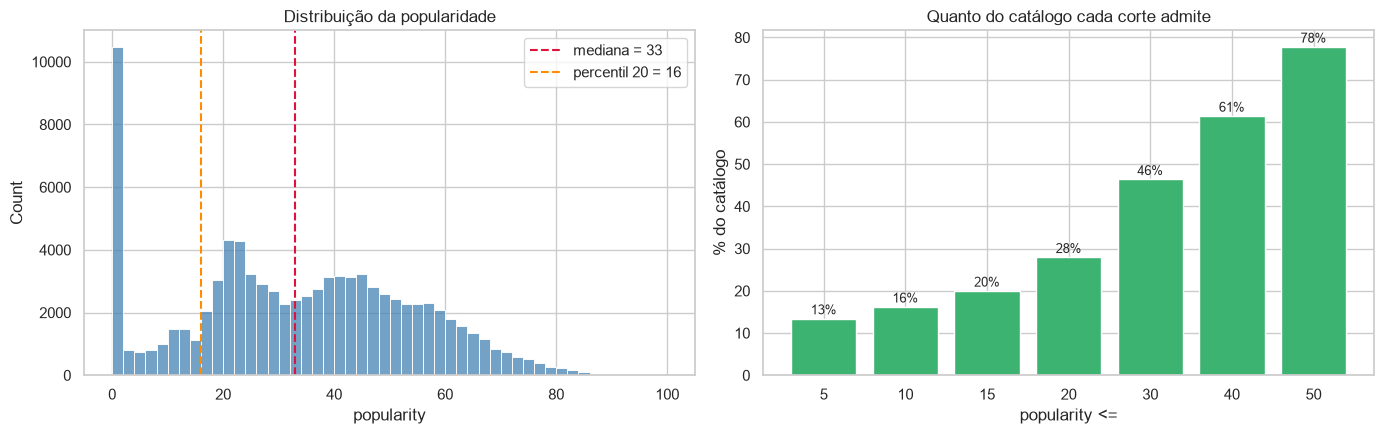

In [14]:
p = faixas["popularity"]
print(p.describe().round(1).to_string())
print(f"\nfaixas com popularity == 0: {(p == 0).sum():,} ({(p == 0).mean()*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(p, bins=50, color="steelblue", ax=ax1)
ax1.axvline(p.median(), color="crimson", ls="--", label=f"mediana = {p.median():.0f}")
ax1.axvline(p.quantile(.20), color="darkorange", ls="--",
            label=f"percentil 20 = {p.quantile(.20):.0f}")
ax1.set_title("Distribuição da popularidade"); ax1.set_xlabel("popularity"); ax1.legend()

cortes = [5, 10, 15, 20, 30, 40, 50]
pcts = [(p <= c).mean()*100 for c in cortes]
ax2.bar([str(c) for c in cortes], pcts, color="mediumseagreen")
for i, v in enumerate(pcts):
    ax2.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax2.set_title("Quanto do catálogo cada corte admite")
ax2.set_xlabel("popularity <="); ax2.set_ylabel("% do catálogo")
plt.tight_layout(); plt.show()

O pico em zero é o que justifica um **piso**: um corte só por percentil
incluiria muita faixa de popularidade 0, que é ruído (sem streams ou não
capturada), não joia escondida.

In [15]:
PISO = 2
TETO = faixas["popularity"].quantile(0.20)
faixas["faixa_obscura"] = (faixas.popularity > PISO) & (faixas.popularity < TETO)
print(f"Corte por FAIXA: {PISO} < popularity < {TETO:.0f}")
print(f"  {faixas.faixa_obscura.sum():,} faixas ({faixas.faixa_obscura.mean()*100:.1f}% do catálogo)")

Corte por FAIXA: 2 < popularity < 16
  6,956 faixas (7.8% do catálogo)


## 4. Normalização — e por que MinMax nesta etapa

Escolha que muda o resultado das próximas células, então fica registrada aqui.

As features estão em escalas incompatíveis: `tempo` vai de 0 a 243, `loudness`
de −49 a 4, e as demais de 0 a 1. Sem normalizar, qualquer medida baseada em
variância compara **unidade**, não informação.

Mas o normalizador certo depende do uso:

| Uso | Normalizador | Por quê |
|---|---|---|
| Variance Threshold, MAD, Dispersion Ratio | **MinMax** | Precisa que a variância seja comparável entre features. **Depois do `StandardScaler` toda variância vale exatamente 1**, e as três técnicas perdem o sentido — não cortariam nada, por construção |
| K-Means, similaridade de cosseno | **StandardScaler** | Distância euclidiana quer média 0 e desvio 1, para nenhuma feature dominar por amplitude |

Ou seja: os dois aparecem no notebook, cada um onde é válido.

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

CONTINUAS = ["danceability", "energy", "valence", "acousticness", "speechiness",
             "instrumentalness", "liveness", "loudness", "tempo", "duration_ms"]
CATEGORICAS = ["key", "mode", "time_signature", "explicit"]

# A seleção roda sobre o catálogo JÁ LIMPO (§2.2). A ordem importa: as faixas
# faladas têm speechiness extremo e distorcem a avaliação dessa feature.
selecao = faixas[faixas.e_musica]
print(f"base da seleção: {len(selecao):,} faixas musicais "
      f"(de {len(faixas):,} no total)")

X_minmax = pd.DataFrame(MinMaxScaler().fit_transform(selecao[CONTINUAS]),
                        columns=CONTINUAS, index=selecao.index)

# Demonstração de que o StandardScaler zeraria a comparação de variância
X_padrao = pd.DataFrame(StandardScaler().fit_transform(selecao[CONTINUAS]),
                        columns=CONTINUAS, index=selecao.index)
print("variância após MinMax (comparável, informativa):")
print(X_minmax.var().sort_values().round(5).to_string())
print("\nvariância após StandardScaler (toda igual a 1 — inútil para VT/MAD):")
print(X_padrao.var().round(3).to_string())

base da seleção: 88,945 faixas musicais (de 89,740 no total)
variância após MinMax (comparável, informativa):
duration_ms         0.00046
speechiness         0.00769
loudness            0.00932
tempo               0.01525
danceability        0.03240
liveness            0.03550
energy              0.06606
valence             0.07006
instrumentalness    0.10554
acousticness        0.11429

variância após StandardScaler (toda igual a 1 — inútil para VT/MAD):
danceability        1.0
energy              1.0
valence             1.0
acousticness        1.0
speechiness         1.0
instrumentalness    1.0
liveness            1.0
loudness            1.0
tempo               1.0
duration_ms         1.0


## 5. Correlação de Pearson

Duas leituras: multicolinearidade **entre** os atributos, e relação de cada um
com a popularidade.

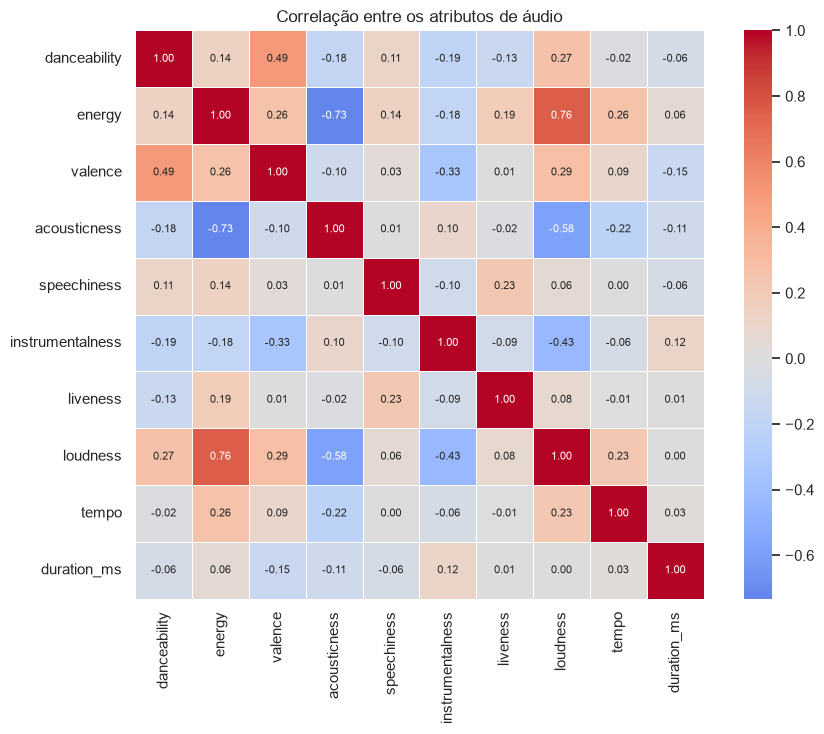

pares com |r| >= 0.30 (redundância a considerar):
  energy             x loudness           r = +0.759
  energy             x acousticness       r = -0.733
  acousticness       x loudness           r = -0.583
  danceability       x valence            r = +0.493
  instrumentalness   x loudness           r = -0.435
  valence            x instrumentalness   r = -0.331


In [17]:
corr = faixas[CONTINUAS].corr()
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlação entre os atributos de áudio")
plt.tight_layout(); plt.show()

pares = [(a, b, corr.loc[a, b]) for i, a in enumerate(CONTINUAS)
         for b in CONTINUAS[i+1:]]
print("pares com |r| >= 0.30 (redundância a considerar):")
for a, b, r in sorted(pares, key=lambda t: -abs(t[2])):
    if abs(r) >= .30:
        print(f"  {a:18} x {b:18} r = {r:+.3f}")

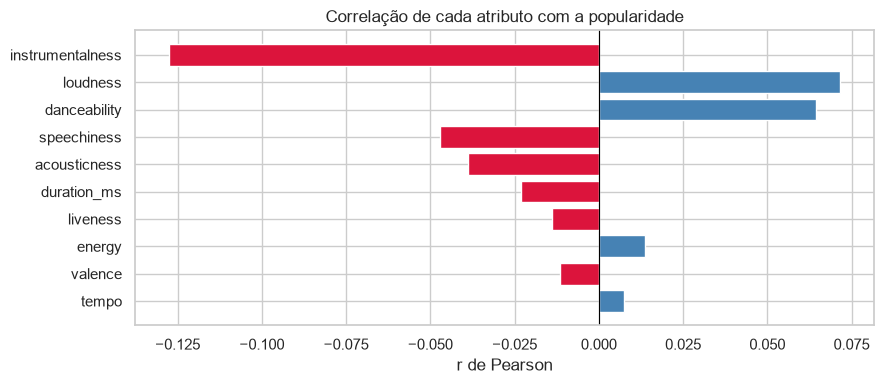

instrumentalness   -0.1276
loudness            0.0717
danceability        0.0643
speechiness        -0.0472
acousticness       -0.0388
duration_ms        -0.0232
liveness           -0.0140
energy              0.0136
valence            -0.0115
tempo               0.0073

maior |r| = 0.128


In [18]:
rp = faixas[CONTINUAS + ["popularity"]].corr()["popularity"].drop("popularity")
rp = rp.reindex(rp.abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 4))
cores = ["crimson" if v < 0 else "steelblue" for v in rp]
ax.barh(rp.index[::-1], rp.values[::-1], color=cores[::-1])
ax.axvline(0, color="black", lw=.8)
ax.set_title("Correlação de cada atributo com a popularidade")
ax.set_xlabel("r de Pearson")
plt.tight_layout(); plt.show()

print(rp.round(4).to_string())
print(f"\nmaior |r| = {rp.abs().max():.3f}")

**Leitura que orienta todo o resto:** a maior correlação de qualquer atributo
com a popularidade é próxima de zero. **Áudio não prediz popularidade.**

Duas consequências:

1. Selecionar features "por relevância à popularidade" seria selecionar em cima
   de ruído. O alvo útil para as técnicas supervisionadas é o **gênero**, que é
   o único rótulo real do dataset.
2. Isso **sustenta a premissa do projeto**: se qualidade sonora não explica
   popularidade, então existem faixas boas e impopulares — é o que buscamos.

## 6. Seleção de features — as 7 Common Filter Techniques

Testamos as sete, **incluindo os categóricos** (`key`, `mode`,
`time_signature`, `explicit`), que não devem ser descartados por suposição.

Alvos possíveis para as técnicas supervisionadas:

- **gênero** (114 classes) — o único rótulo real
- **faixa obscura** (binário) — relevante ao produto

In [19]:
from sklearn.feature_selection import chi2, mutual_info_classif, VarianceThreshold
from scipy.stats import chi2_contingency

# alvo 1: gênero primário (o primeiro da lista, para ter um rótulo por faixa)
y_genero = selecao["generos"].str[0]
# alvo 2: faixa obscura
y_obscura = selecao["faixa_obscura"].astype(int)
X_cat = selecao[CATEGORICAS].astype(int)
print(f"alvo gênero: {y_genero.nunique()} classes | alvo obscura: {y_obscura.mean()*100:.1f}% positivos")

alvo gênero: 113 classes | alvo obscura: 7.8% positivos


In [20]:
# ---- 1. Variance Threshold (sobre MinMax) ----
var = X_minmax.var().sort_values()
print("=== 1. VARIANCE THRESHOLD ===")
print(var.round(5).to_string())
for lim in (0.01, 0.02, 0.05):
    vt = VarianceThreshold(threshold=lim).fit(X_minmax)
    corta = [c for c, k in zip(CONTINUAS, vt.get_support()) if not k]
    print(f"  limiar {lim:.2f} -> corta: {corta if corta else 'nada'}")

# ---- 2. Mean Absolute Difference ----
mad = (X_minmax - X_minmax.mean()).abs().mean().sort_values(ascending=False)
print("\n=== 2. MEAN ABSOLUTE DIFFERENCE ===")
print(mad.round(5).to_string())

# ---- 3. Dispersion Ratio ----
EPS = 1e-6
disp = {c: (X_minmax[c] + EPS).mean() / np.exp(np.log(X_minmax[c] + EPS).mean())
        for c in CONTINUAS}
print("\n=== 3. DISPERSION RATIO ===")
for c, v in sorted(disp.items(), key=lambda t: -t[1]):
    print(f"  {c:18} {v:12.2f}")
print("  ATENÇÃO: o ratio explode com muitos zeros (instrumentalness tem")
print("  dezenas de milhares). Aqui ele mede ESPARSIDADE, não utilidade —")
print("  por isso não entra na decisão final.")

=== 1. VARIANCE THRESHOLD ===
duration_ms         0.00046
speechiness         0.00769
loudness            0.00932
tempo               0.01525
danceability        0.03240
liveness            0.03550
energy              0.06606
valence             0.07006
instrumentalness    0.10554
acousticness        0.11429
  limiar 0.01 -> corta: ['speechiness', 'loudness', 'duration_ms']
  limiar 0.02 -> corta: ['speechiness', 'loudness', 'tempo', 'duration_ms']
  limiar 0.05 -> corta: ['danceability', 'speechiness', 'liveness', 'loudness', 'tempo', 'duration_ms']

=== 2. MEAN ABSOLUTE DIFFERENCE ===
acousticness        0.29779
instrumentalness    0.25740
valence             0.22601
energy              0.21498
danceability        0.14512
liveness            0.13555
tempo               0.09875
loudness            0.06857
speechiness         0.05621
duration_ms         0.01255

=== 3. DISPERSION RATIO ===
  instrumentalness         626.19
  acousticness               5.00
  speechiness                

In [21]:
# ---- 4. Chi-square: o teste dos CATEGÓRICOS ----
print("=== 4. CHI-SQUARE (categóricos) ===")
for nome, y in [("gênero", y_genero), ("faixa obscura", y_obscura)]:
    est, pval = chi2(X_cat, y)
    print(f"  alvo = {nome}")
    for c, e, pv in sorted(zip(CATEGORICAS, est, pval), key=lambda t: -t[1]):
        sig = "significativo" if pv < .05 else "NÃO significativo"
        print(f"    {c:16} chi2={e:11.1f}  p={pv:.2e}  {sig}")

# ---- 5. Cramér's V: a leitura normalizada ----
def cramers_v(a, b):
    tab = pd.crosstab(a, b)
    chi = chi2_contingency(tab, correction=False)[0]
    return np.sqrt((chi / tab.values.sum()) / (min(tab.shape) - 1))

print("\n=== 5. CRAMÉR'S V (associação normalizada) ===")
for c in CATEGORICAS:
    print(f"  {c:16} x gênero  V={cramers_v(selecao[c], y_genero):.4f}"
          f"   | x obscura  V={cramers_v(selecao[c], y_obscura):.4f}")
print("  chi2 infla com cardinalidade; V normaliza. Quando os dois discordam,")
print("  V é a leitura honesta.")

=== 4. CHI-SQUARE (categóricos) ===


  alvo = gênero
    explicit         chi2=    13292.0  p=0.00e+00  significativo
    mode             chi2=     2100.5  p=0.00e+00  significativo
    key              chi2=     1321.0  p=1.52e-205  significativo
    time_signature   chi2=      324.0  p=1.77e-22  significativo
  alvo = faixa obscura
    explicit         chi2=      155.3  p=1.19e-35  significativo
    key              chi2=       23.3  p=1.40e-06  significativo
    mode             chi2=       15.5  p=8.30e-05  significativo
    time_signature   chi2=        0.0  p=8.72e-01  NÃO significativo

=== 5. CRAMÉR'S V (associação normalizada) ===
  key              x gênero  V=0.0904   | x obscura  V=0.0472
  mode             x gênero  V=0.2549   | x obscura  V=0.0219
  time_signature   x gênero  V=0.2428   | x obscura  V=0.0202


  explicit         x gênero  V=0.4032   | x obscura  V=0.0436
  chi2 infla com cardinalidade; V normaliza. Quando os dois discordam,
  V é a leitura honesta.


In [22]:
# ---- 6. Information Gain (mutual info: serve contínua E discreta) ----
TODAS = CONTINUAS + CATEGORICAS
X_todas = pd.concat([X_minmax, X_cat], axis=1)[TODAS]
discretas = [c in CATEGORICAS for c in TODAS]

rng = np.random.default_rng(42)
amo_mi = rng.choice(len(X_todas), 15000, replace=False)
Xa = X_todas.iloc[amo_mi]

mi_resultados = {}
print("=== 6. INFORMATION GAIN ===")
for nome, y in [("gênero", y_genero), ("faixa obscura", y_obscura)]:
    mi = mutual_info_classif(Xa, y.iloc[amo_mi], discrete_features=discretas,
                             random_state=42)
    mi_resultados[nome] = pd.Series(mi, index=TODAS).sort_values(ascending=False)
    print(f"  alvo = {nome}")
    for c, v in mi_resultados[nome].items():
        print(f"    {c:18} MI={v:.4f}{'  [cat]' if c in CATEGORICAS else ''}")

=== 6. INFORMATION GAIN ===


  alvo = gênero
    acousticness       MI=0.5440
    energy             MI=0.4510
    loudness           MI=0.3848
    danceability       MI=0.3741
    tempo              MI=0.3700
    instrumentalness   MI=0.3676
    duration_ms        MI=0.3445
    valence            MI=0.3144
    speechiness        MI=0.2275
    liveness           MI=0.1444
    key                MI=0.0806  [cat]
    explicit           MI=0.0716  [cat]
    time_signature     MI=0.0675  [cat]
    mode               MI=0.0375  [cat]


  alvo = faixa obscura
    instrumentalness   MI=0.0244
    duration_ms        MI=0.0141
    loudness           MI=0.0083
    acousticness       MI=0.0079
    danceability       MI=0.0073
    tempo              MI=0.0041
    energy             MI=0.0020
    valence            MI=0.0018
    explicit           MI=0.0014  [cat]
    key                MI=0.0010  [cat]
    liveness           MI=0.0008
    time_signature     MI=0.0004  [cat]
    mode               MI=0.0002  [cat]
    speechiness        MI=0.0000


In [23]:
# ---- 7. Fisher's Score ----
def fisher_score(X, y):
    media_geral, out = X.mean(), {}
    for c in X.columns:
        num = den = 0.0
        for _, grupo in X[c].groupby(y):
            n = len(grupo)
            num += n * (grupo.mean() - media_geral[c]) ** 2
            den += n * grupo.var(ddof=0)
        out[c] = num / den if den else np.nan
    return pd.Series(out).sort_values(ascending=False)

print("=== 7. FISHER'S SCORE ===")
fisher_resultados = {}
for nome, y in [("gênero", y_genero), ("faixa obscura", y_obscura)]:
    f = fisher_score(X_todas, y)
    fisher_resultados[nome] = f
    print(f"  alvo = {nome}")
    for c, v in f.items():
        print(f"    {c:18} F={v:.4f}{'  [cat]' if c in CATEGORICAS else ''}")

=== 7. FISHER'S SCORE ===


  alvo = gênero
    acousticness       F=0.9875
    energy             F=0.8838
    loudness           F=0.8548
    instrumentalness   F=0.8522
    danceability       F=0.7650
    valence            F=0.4893
    duration_ms        F=0.2093
    speechiness        F=0.1954
    explicit           F=0.1941  [cat]
    liveness           F=0.1304
    tempo              F=0.1012
    time_signature     F=0.0771  [cat]
    mode               F=0.0695  [cat]
    key                F=0.0062  [cat]
  alvo = faixa obscura
    instrumentalness   F=0.0515
    loudness           F=0.0063
    duration_ms        F=0.0036
    acousticness       F=0.0022
    danceability       F=0.0021
    explicit           F=0.0019  [cat]
    liveness           F=0.0018
    speechiness        F=0.0007
    mode               F=0.0005  [cat]
    valence            F=0.0002
    key                F=0.0001  [cat]
    tempo              F=0.0000
    time_signature     F=0.0000  [cat]
    energy             F=0.0000


=== PLACAR CONSOLIDADO (rank_medio menor = melhor) ===
                  variancia_minmax     MAD  MI_genero  Fisher_genero  rank_medio
acousticness                0.1143  0.2978     0.5440         0.9875      0.0857
energy                      0.0661  0.2150     0.4510         0.8838      0.2714
instrumentalness            0.1055  0.2574     0.3676         0.8522      0.2786
valence                     0.0701  0.2260     0.3144         0.4893      0.4000
danceability                0.0324  0.1451     0.3741         0.7650      0.4357
loudness                    0.0093  0.0686     0.3848         0.8548      0.5071
liveness                    0.0355  0.1355     0.1444         0.1304      0.6321
tempo                       0.0152  0.0987     0.3700         0.1012      0.6357
explicit                       NaN     NaN     0.0716         0.1941      0.7500
duration_ms                 0.0005  0.0126     0.3445         0.2093      0.7500
speechiness                 0.0077  0.0562     0.2275 

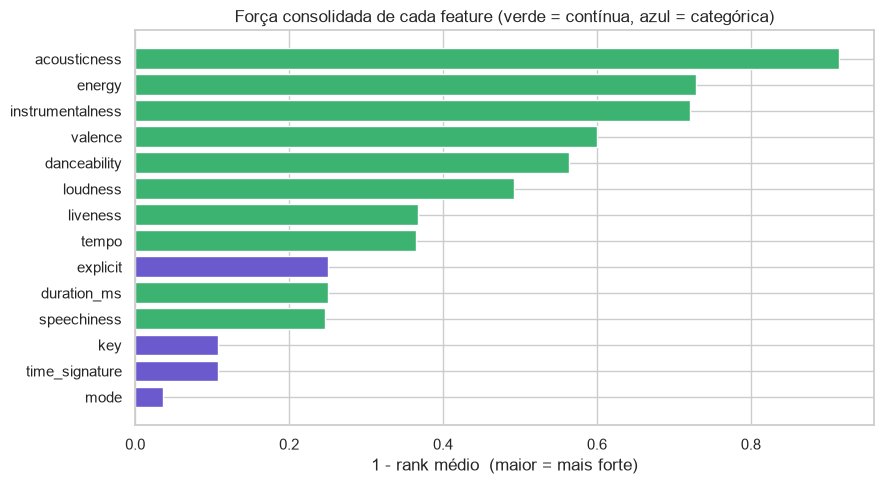

In [24]:
# ---- Consolidação: quem sobrevive a várias técnicas? ----
placar = pd.DataFrame({
    "variancia_minmax": X_minmax.var().reindex(TODAS),
    "MAD": (X_minmax - X_minmax.mean()).abs().mean().reindex(TODAS),
    "MI_genero": mi_resultados["gênero"].reindex(TODAS),
    "Fisher_genero": fisher_resultados["gênero"].reindex(TODAS),
})
# rank normalizado (1 = melhor) por técnica, e média dos ranks
ranks = placar.rank(ascending=False, pct=True)
placar["rank_medio"] = ranks.mean(axis=1)
placar = placar.sort_values("rank_medio")
print("=== PLACAR CONSOLIDADO (rank_medio menor = melhor) ===")
print(placar.round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
cor = ["mediumseagreen" if c not in CATEGORICAS else "slateblue"
       for c in placar.index]
ax.barh(placar.index[::-1], (1 - placar.rank_medio)[::-1], color=cor[::-1])
ax.set_title("Força consolidada de cada feature (verde = contínua, azul = categórica)")
ax.set_xlabel("1 - rank médio  (maior = mais forte)")
plt.tight_layout(); plt.show()

### Descartes por evidência

| Feature | Motivo |
|---|---|
| `loudness` | Redundante com `energy` (r ≈ 0,76) e variância baixa. Contar o mesmo eixo duas vezes distorce a distância |
| `duration_ms` | A menor variância de todas, por ampla margem |
| `tempo` | Variância baixa e Fisher baixo; o MI alto vem da escala própria, não de separabilidade |
| `liveness` | Fraca em todas as técnicas |
| `key` | Fisher ≈ 0,005 e Cramér's V ≈ 0,09 — última nas duas leituras |
| `mode`, `time_signature` | V ≈ 0,25 com gênero, mas não descrevem timbre nem humor |
| `explicit` | **O categórico mais forte** (V ≈ 0,40 com gênero). Fica fora do vetor de mood por julgamento, não por fraqueza: é metadado de **letra**, não de som. Entra na análise de gênero |

Os categóricos, portanto, **não foram descartados por suposição** — foram
testados, reportados, e um deles (`explicit`) é estatisticamente relevante para
gênero. O que a evidência mostra é que nenhum deles descreve *humor musical*.

### O caso do `speechiness`: por que ele também sai

Duas evidências independentes, e a primeira mostra por que **a ordem
limpar → selecionar importa**.

Se a seleção rodasse no catálogo inteiro, as faixas faladas identificadas na
seção 2.2 — menos de 1% dos dados — inflariam a aparente importância do
`speechiness`, porque nelas essa feature é extrema. Rodando as duas versões
lado a lado:

In [25]:
# A ordem importa: comparamos a seleção no catálogo inteiro e no já limpo.
fs_comparacao = {}
for rotulo, base in [("inteiro", faixas), ("musical", selecao)]:
    Xm = pd.DataFrame(MinMaxScaler().fit_transform(base[CONTINUAS]),
                      columns=CONTINUAS, index=base.index)
    Xt = pd.concat([Xm, base[CATEGORICAS].astype(int)], axis=1)
    fs_comparacao[rotulo] = fisher_score(Xt, base["generos"].str[0])

fi, fm = fs_comparacao["inteiro"], fs_comparacao["musical"]
pos_i = list(fi.index).index("speechiness") + 1
pos_m = list(fm.index).index("speechiness") + 1

print("=== Fisher do speechiness, antes e depois de limpar ===")
print(f"  catálogo inteiro: {fi['speechiness']:.3f}  ({pos_i}º de {len(fi)})")
print(f"  só musical      : {fm['speechiness']:.3f}  ({pos_m}º de {len(fm)})")
print(f"  queda de {fi['speechiness']/fm['speechiness']:.1f}x")

print()
print("=== e as outras features? (praticamente inalteradas) ===")
for c in ["acousticness", "energy", "instrumentalness", "danceability", "valence"]:
    print(f"  {c:18} {fi[c]:>7.3f} -> {fm[c]:>6.3f}")

=== Fisher do speechiness, antes e depois de limpar ===
  catálogo inteiro: 0.906  (2º de 14)
  só musical      : 0.195  (8º de 14)
  queda de 4.6x

=== e as outras features? (praticamente inalteradas) ===
  acousticness         1.012 ->  0.987
  energy               0.878 ->  0.884
  instrumentalness     0.857 ->  0.852
  danceability         0.761 ->  0.765
  valence              0.484 ->  0.489


**Na ordem correta, a própria seleção de features rejeita o `speechiness`:** ele
despenca no ranking, com o Fisher caindo várias vezes. As outras cinco features
ficam praticamente inalteradas — a distorção era exclusivamente dele.

A segunda evidência é o que ele faz **dentro do cluster**: não mede humor, mede
presença vocal, que atravessa todos os humores.

In [26]:
# Diagnostico: o que o speechiness agrupa de fato?
from sklearn.cluster import KMeans

X6 = StandardScaler().fit_transform(
    faixas[["danceability", "energy", "valence", "acousticness",
            "instrumentalness", "speechiness"]])
km6 = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X6)
faixas["_c6"] = km6.labels_
c_speech = faixas.groupby("_c6")["speechiness"].mean().idxmax()
c2 = faixas[faixas._c6 == c_speech]

print(f"cluster de speechiness alto: {len(c2):,} faixas "
      f"({len(c2)/len(faixas)*100:.1f}% do catálogo)")
print(f"speechiness médio: {c2.speechiness.mean():.3f}\n")
print("distribuição pelas bandas do Spotify:")
bandas = {"música (< 0,33)": c2.speechiness < .33,
          "rap / misto (0,33-0,66)": (c2.speechiness >= .33) & (c2.speechiness <= .66),
          "falado (> 0,66)": c2.speechiness > .66}
for nome, m in bandas.items():
    top = pd.Series([g for l in c2[m].generos for g in l]).value_counts().head(5)
    print(f"  {nome:24} {m.sum():>6,} ({m.mean()*100:5.1f}%)  -> {', '.join(top.index)}")

cluster de speechiness alto: 3,906 faixas (4.4% do catálogo)
speechiness médio: 0.501

distribuição pelas bandas do Spotify:
  música (< 0,33)             775 ( 19.8%)  -> j-dance, dancehall, turkish, french, sad
  rap / misto (0,33-0,66)   2,263 ( 57.9%)  -> j-dance, funk, dancehall, kids, french
  falado (> 0,66)             868 ( 22.2%)  -> comedy, kids, children, show-tunes, funk


In [27]:
# E onde estao rap/hip-hop de verdade? (a pergunta que desmonta a hipotese)
print("speechiness médio por gênero vocalmente denso:")
fg2 = faixa_genero.merge(faixas[["_c6", "speechiness"]], left_on="track_id",
                         right_index=True)
for g in ["hip-hop", "r-n-b", "dancehall", "funk", "reggaeton", "comedy"]:
    s = fg2[fg2.genero == g]
    if len(s):
        pct = (s._c6 == c_speech).mean() * 100
        print(f"  {g:12} n={len(s):>5,}  speechiness={s.speechiness.mean():.3f}  "
              f"| {pct:4.1f}% no cluster de speechiness alto")

speechiness médio por gênero vocalmente denso:
  hip-hop      n=  991  speechiness=0.130  |  8.3% no cluster de speechiness alto
  r-n-b        n=1,000  speechiness=0.089  |  5.6% no cluster de speechiness alto
  dancehall    n=  999  speechiness=0.187  | 20.3% no cluster de speechiness alto
  funk         n=1,000  speechiness=0.152  | 17.6% no cluster de speechiness alto
  reggaeton    n=1,000  speechiness=0.121  |  7.4% no cluster de speechiness alto


  comedy       n=  996  speechiness=0.756  | 84.2% no cluster de speechiness alto


**O que isso mostra:** o cluster que o `speechiness` cria tem 58% na banda
ambígua, 22% em conteúdo genuinamente falado (comédia, infantil, show-tunes) e
20% em música. Não é um humor — é uma mistura.

E o argumento decisivo: **rap e hip-hop não estão nele.** `hip-hop` tem
`speechiness` médio de ~0,13, bem na banda de "música", e a maioria das suas
faixas cai no cluster dançante. O que o `speechiness` isola não é o rap: é
comédia e conteúdo infantil.

Comparando os dois conjuntos de features de forma direta:

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

rng_cmp = np.random.default_rng(42)
CONJUNTOS = {
    "6 features (com speechiness)": ["danceability", "energy", "valence",
                                     "acousticness", "instrumentalness", "speechiness"],
    "5 features (sem speechiness)": ["danceability", "energy", "valence",
                                     "acousticness", "instrumentalness"],
}
print(f"{'conjunto':32} {'K':>3} {'silhouette':>11} {'davies_bouldin':>15}")
print("-" * 64)
for nome, feats in CONJUNTOS.items():
    Xc_ = StandardScaler().fit_transform(faixas[feats])
    amo_ = rng_cmp.choice(len(Xc_), 15000, replace=False)
    for k in (3, 4, 5):
        km_ = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc_)
        print(f"{nome:32} {k:>3} {silhouette_score(Xc_[amo_], km_.labels_[amo_]):>11.3f}"
              f" {davies_bouldin_score(Xc_, km_.labels_):>15.3f}")
faixas.drop(columns=["_c6"], inplace=True)

conjunto                           K  silhouette  davies_bouldin
----------------------------------------------------------------


6 features (com speechiness)       3       0.231           1.522


6 features (com speechiness)       4       0.246           1.322


6 features (com speechiness)       5       0.257           1.230


5 features (sem speechiness)       3       0.259           1.368


5 features (sem speechiness)       4       0.274           1.239


5 features (sem speechiness)       5       0.290           1.116


Sem `speechiness` o resultado é melhor em **todas** as combinações: silhouette
mais alto e Davies-Bouldin mais baixo. E, mais importante que a métrica, os
quatro grupos passam a ser interpretáveis.

**Vetor de mood final — 5 features:** `danceability`, `energy`, `valence`,
`acousticness`, `instrumentalness`.

In [29]:
FEATURES_MOOD = ["danceability", "energy", "valence",
                 "acousticness", "instrumentalness"]

# Clusterizamos apenas o catálogo musical: conteúdo falado não tem humor
# musical e puxaria os centroides.
MUSICAL = faixas.index[faixas.e_musica]

scaler = StandardScaler()                      # StandardScaler aqui: K-Means
X_mood = scaler.fit_transform(faixas.loc[MUSICAL, FEATURES_MOOD])
print(f"vetor de mood: {X_mood.shape[0]:,} faixas x {X_mood.shape[1]} features")
print(f"features: {', '.join(FEATURES_MOOD)}")
print(f"fora da clusterização (conteúdo falado): {(~faixas.e_musica).sum():,}")

vetor de mood: 88,945 faixas x 5 features
features: danceability, energy, valence, acousticness, instrumentalness
fora da clusterização (conteúdo falado): 795


## 7. Clusterização em moods

### Validação do K — testando de 3 a 8

O número de clusters não é escolha de gosto: é hipótese a validar. Testamos
K = 3 a 8 com quatro critérios, porque um só pode enganar.

| Critério | Direção | O que mede |
|---|---|---|
| **Inertia** | menor é melhor, mas cai sempre | Soma das distâncias ao centroide. Nunca aponta um K sozinha — procura-se o *joelho*, onde a queda desacelera |
| **Silhouette** | maior é melhor | Quão bem cada ponto cabe no seu cluster comparado ao vizinho mais próximo |
| **Davies-Bouldin** | **menor** é melhor | Razão entre dispersão interna e separação entre clusters |
| **Calinski-Harabasz** | maior é melhor | Variância entre clusters sobre variância interna. Tende a favorecer K pequeno |

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)

rng = np.random.default_rng(42)
amo = rng.choice(len(X_mood), 20000, replace=False)

validacao = []
modelos = {}
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_mood)
    modelos[k] = km
    tam = pd.Series(km.labels_).value_counts()
    validacao.append({
        "K": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_mood[amo], km.labels_[amo]),
        "davies_bouldin": davies_bouldin_score(X_mood, km.labels_),
        "calinski_harabasz": calinski_harabasz_score(X_mood, km.labels_),
        "menor_cluster_pct": tam.min() / len(X_mood) * 100,
    })

val = pd.DataFrame(validacao).set_index("K")
print(val.round(3).to_string())

print("\n=== vencedor por critério ===")
print(f"  silhouette (máx)        -> K={val.silhouette.idxmax()}")
print(f"  davies_bouldin (mín)    -> K={val.davies_bouldin.idxmin()}")
print(f"  calinski_harabasz (máx) -> K={val.calinski_harabasz.idxmax()}")

print("\n=== joelho: quanto a inertia cai a cada passo ===")
for a, b in zip(val.index[:-1], val.index[1:]):
    q = (val.loc[a, "inertia"] - val.loc[b, "inertia"]) / val.loc[a, "inertia"] * 100
    print(f"  K={a} -> {b}: reduz {q:5.1f}%")

      inertia  silhouette  davies_bouldin  calinski_harabasz  menor_cluster_pct
K                                                                              
3  246371.438       0.262           1.360          35803.703             24.272
4  207746.209       0.276           1.238          33818.811              8.708
5  171819.060       0.292           1.117          35316.671              7.563
6  155727.809       0.267           1.206          33010.370              7.280
7  142477.442       0.259           1.159          31445.268              7.255
8  131188.910       0.263           1.182          30365.214              4.912

=== vencedor por critério ===
  silhouette (máx)        -> K=5
  davies_bouldin (mín)    -> K=5
  calinski_harabasz (máx) -> K=3

=== joelho: quanto a inertia cai a cada passo ===
  K=3 -> 4: reduz  15.7%
  K=4 -> 5: reduz  17.3%
  K=5 -> 6: reduz   9.4%
  K=6 -> 7: reduz   8.5%
  K=7 -> 8: reduz   7.9%


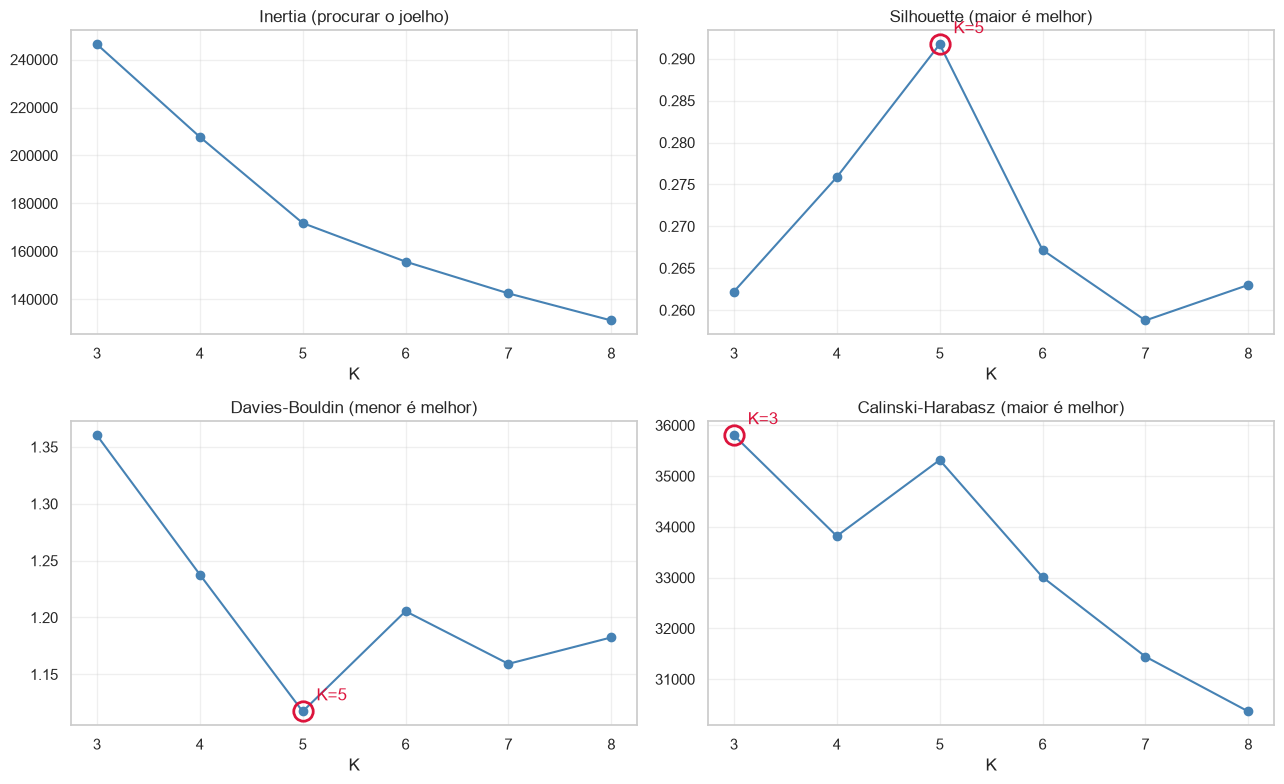

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, (col, titulo, melhor) in zip(axes.flat, [
        ("inertia", "Inertia (procurar o joelho)", None),
        ("silhouette", "Silhouette (maior é melhor)", val.silhouette.idxmax()),
        ("davies_bouldin", "Davies-Bouldin (menor é melhor)", val.davies_bouldin.idxmin()),
        ("calinski_harabasz", "Calinski-Harabasz (maior é melhor)", val.calinski_harabasz.idxmax())]):
    ax.plot(val.index, val[col], "o-", color="steelblue")
    if melhor is not None:
        ax.plot(melhor, val.loc[melhor, col], "o", ms=14, mfc="none",
                mec="crimson", mew=2)
        ax.annotate(f"K={melhor}", (melhor, val.loc[melhor, col]),
                    textcoords="offset points", xytext=(10, 8), color="crimson")
    ax.set_title(titulo); ax.set_xlabel("K"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Resultado: K = 5, e os critérios convergem.**

- **Silhouette** é máximo em K=5
- **Davies-Bouldin** é mínimo em K=5
- O **joelho da inertia** está em K=5: a queda de 4→5 é a maior da série, e o
  passo seguinte (5→6) cai para pouco mais da metade
- **Calinski-Harabasz** aponta K=3, mas esse índice favorece sistematicamente
  poucos clusters e é o único fora do consenso

Também importa que nenhum cluster fica minúsculo — o menor tem ~7,5% do
catálogo, então não é um K que criou um grupo residual.

**Nota metodológica:** uma versão anterior deste trabalho usou K=4 escolhido
"por produto", com o argumento de que queríamos quatro vibes de uso. Os dados
não sustentam isso. O que o K=5 revela é uma distinção musical real que o K=4
apagava — ver a interpretação a seguir.

In [32]:
K = 5
kmeans = modelos[K]
faixas["cluster"] = pd.Series(kmeans.labels_, index=MUSICAL)

print(f"=== métricas finais (K={K}) ===")
print(f"  Silhouette        : {val.loc[K, 'silhouette']:.3f}  (perto de 1 é melhor)")
print(f"  Davies-Bouldin    : {val.loc[K, 'davies_bouldin']:.3f}  (perto de 0 é melhor)")
print(f"  Calinski-Harabasz : {val.loc[K, 'calinski_harabasz']:,.0f}  (maior é melhor)")

perfil = faixas.groupby("cluster")[FEATURES_MOOD].mean().round(3)
perfil["n_faixas"] = faixas.cluster.value_counts().sort_index()
perfil["pop_media"] = faixas.groupby("cluster")["popularity"].mean().round(1)
print("\n=== perfil médio de cada cluster (features originais) ===")
print(perfil.to_string())

=== métricas finais (K=5) ===
  Silhouette        : 0.292  (perto de 1 é melhor)
  Davies-Bouldin    : 1.117  (perto de 0 é melhor)
  Calinski-Harabasz : 35,317  (maior é melhor)

=== perfil médio de cada cluster (features originais) ===
         danceability  energy  valence  acousticness  instrumentalness  n_faixas  pop_media
cluster                                                                                    
0.0             0.696   0.721    0.720         0.237             0.022     30238       34.3
1.0             0.514   0.372    0.387         0.720             0.021     18468       33.0
2.0             0.572   0.765    0.337         0.087             0.790     10268       27.1
3.0             0.478   0.798    0.346         0.075             0.031     23244       36.0
4.0             0.367   0.196    0.204         0.854             0.845      6727       29.9


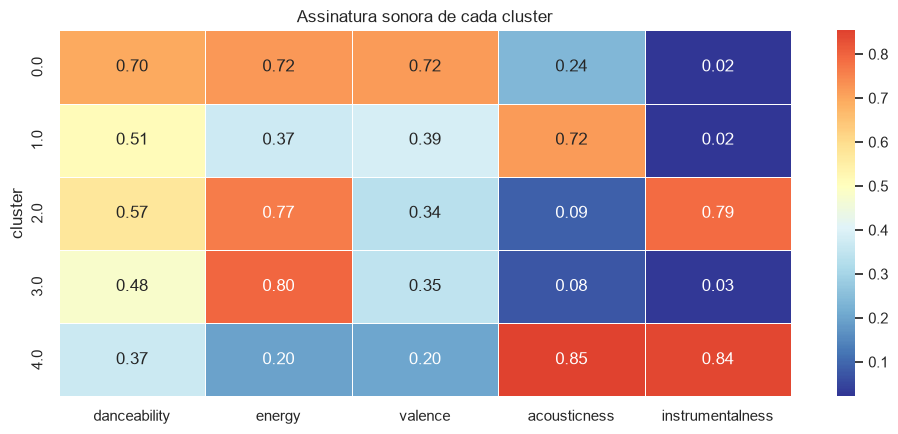

=== gêneros dominantes por cluster ===
  cluster 0 (30,238 faixas): salsa, reggaeton, latino, reggae, forro, dancehall, latin
  cluster 1 (18,468 faixas): tango, romance, jazz, honky-tonk, show-tunes, cantopop, opera
  cluster 2 (10,268 faixas): minimal-techno, detroit-techno, techno, grindcore, trance, chicago-house, idm
  cluster 3 (23,244 faixas): metalcore, heavy-metal, grunge, metal, dubstep, hardstyle, death-metal
  cluster 4 (6,727 faixas): new-age, ambient, sleep, classical, piano, guitar, iranian


In [33]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(faixas.groupby("cluster")[FEATURES_MOOD].mean(), annot=True,
            fmt=".2f", cmap="RdYlBu_r", center=.5, linewidths=.5, ax=ax)
ax.set_title("Assinatura sonora de cada cluster")
plt.tight_layout(); plt.show()

print("=== gêneros dominantes por cluster ===")
fg = faixa_genero.merge(faixas[["cluster"]], left_on="track_id",
                        right_index=True)
for c in range(K):
    top = fg[fg.cluster == c]["genero"].value_counts().head(7)
    print(f"  cluster {c} ({(faixas.cluster == c).sum():,} faixas): {', '.join(top.index)}")

### O que o K=5 revelou

A estrutura é um **2×2 mais um**. Dois eixos organizam quase tudo: energia
(calmo × intenso) e `instrumentalness` (com voz × sem voz).

| | **Com voz** (`instrumentalness` ≈ 0,02) | **Sem voz** (`instrumentalness` ≈ 0,8) |
|---|---|---|
| **Calmo** (energia ≈ 0,2–0,4) | tango, romance, jazz, opera | new-age, ambient, sleep, classical, piano, study |
| **Intenso** (energia ≈ 0,8) | metalcore, heavy-metal, grunge, dubstep | minimal-techno, detroit-techno, trance, idm |

E fora da grade, o grupo dançante e alegre: salsa, reggaeton, latino, forró.

**É exatamente isso que o K=4 apagava.** Com quatro clusters, techno
instrumental e metal vocal caíam no *mesmo* grupo — só porque ambos têm energia
alta. Musicalmente são coisas diferentes, e a métrica concordou: o K=5 separou
os dois e melhorou silhouette e Davies-Bouldin ao mesmo tempo.

### Os nomes

| Assinatura | Gêneros dominantes | Nome |
|---|---|---|
| dançante, valência alta, com voz | salsa, reggaeton, latino, reggae, forró | **Gingado** |
| calmo, acústico, com voz | tango, romance, jazz, opera | **Aconchego** |
| calmo, acústico, sem voz | new-age, ambient, sleep, classical, study | **Foco** |
| intenso, elétrico, sem voz | minimal-techno, detroit-techno, trance, idm | **Treino** |
| intenso, elétrico, com voz | metalcore, heavy-metal, grunge, dubstep | **Heavy** |

Para trocar qualquer nome, basta editar a célula abaixo — é o único ponto de
escolha estética do notebook.

**Uma convergência que vale registrar:** o cluster **Foco** tem
`instrumentalness` ≈ 0,84 e o `VIBES["foco"]` do protótipo aprovado pede 0,88,
com gêneros literalmente `study` e `sleep`. Um dos cinco moods encontrados nos
dados **é** o Foco que o produto já desenhava à mão. Os outros quatro divergem
do protótipo, e a decisão registrada é que os dados mandam.

In [34]:
# Mapeia cluster -> nome lendo o perfil, para o nome não depender da ordem
# em que o K-Means numerou os clusters nesta execução.
p = faixas.groupby("cluster")[FEATURES_MOOD].mean()

# Eixo 1: tem voz? (instrumentalness baixo = tem voz)
sem_voz = p.index[p["instrumentalness"] > .5].tolist()
com_voz = p.index[p["instrumentalness"] <= .5].tolist()

nomes = {}
# Sem voz: o calmo é Foco, o intenso é Treino
nomes[p.loc[sem_voz, "energy"].idxmin()] = "Foco"
nomes[p.loc[sem_voz, "energy"].idxmax()] = "Treino"
# Com voz: o mais dançante e alegre é Gingado
nomes[p.loc[com_voz, "valence"].idxmax()] = "Gingado"
restantes = [c for c in com_voz if c not in nomes]
# Dos que sobram, o mais energético é Heavy e o mais calmo é Aconchego
nomes[p.loc[restantes, "energy"].idxmax()] = "Heavy"
nomes[p.loc[restantes, "energy"].idxmin()] = "Aconchego"

faixas["mood"] = faixas["cluster"].map(nomes)
print("mapeamento:", {int(k): v for k, v in sorted(nomes.items())})
print("\ndistribuição:")
print(faixas["mood"].value_counts().to_string())
print("\nperfil por mood:")
print(faixas.groupby("mood")[FEATURES_MOOD].mean().round(3).to_string())

mapeamento: {0: 'Gingado', 1: 'Aconchego', 2: 'Treino', 3: 'Heavy', 4: 'Foco'}

distribuição:
mood
Gingado      30238
Heavy        23244
Aconchego    18468
Treino       10268
Foco          6727

perfil por mood:
           danceability  energy  valence  acousticness  instrumentalness
mood                                                                    
Aconchego         0.514   0.372    0.387         0.720             0.021
Foco              0.367   0.196    0.204         0.854             0.845
Gingado           0.696   0.721    0.720         0.237             0.022
Heavy             0.478   0.798    0.346         0.075             0.031
Treino            0.572   0.765    0.337         0.087             0.790


### Os moods batem com as vibes do prototipo?

O protótipo aprovado define quatro vibes — Foco, Treino, Chill e Melancolia —
com alvos numéricos em `src/dados.py::VIBES`.

**Cuidado com o que esses números valem.** Eles foram escritos à mão para o
protótipo navegável, sobre um catálogo de 32 faixas fictícias. São hipótese de
design, não medição. Servem para mostrar onde os dados divergem do que o
produto imaginou, e **não** como referência de verdade sobre o que as pessoas
ouvem.

In [35]:
import sys

# O notebook roda de dentro de notebook/, entao a raiz do repo precisa entrar
# no path para importarmos as constantes do proprio app.
RAIZ = str(CAMINHO.resolve().parent.parent.parent)
if RAIZ not in sys.path:
    sys.path.insert(0, RAIZ)

from src.dados import VIBES, PESOS

EQUIV = {"danceability": "dancabilidade", "energy": "energia",
         "valence": "valencia", "acousticness": "acustica",
         "instrumentalness": "instrumentalidade"}
perfis_pt = faixas.groupby("mood")[FEATURES_MOOD].mean().rename(columns=EQUIV)

def distancia(perfil, alvo):
    return sum(PESOS[k] * abs(perfil[k] - alvo[k]) for k in alvo)

tab = pd.DataFrame({
    v["nome"]: {m: distancia(perfis_pt.loc[m], v["alvo"]) for m in perfis_pt.index}
    for v in VIBES.values()
}).round(3)
print("distancia entre cada vibe imaginada e cada mood medido (menor = mais parecido)")
print()
print(tab.to_string())
print()
for vibe in tab.columns:
    m = tab[vibe].idxmin()
    print(f"  {vibe:12} -> mais proximo: {m:12} (dist {tab.loc[m, vibe]:.3f})")

2026-09-03 09:57:13.365 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-09-03 09:57:13.371 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


distancia entre cada vibe imaginada e cada mood medido (menor = mais parecido)

            Foco  Treino  Chill  Melancolia
Aconchego  0.219   0.400  0.138       0.176
Foco       0.140   0.621  0.264       0.147
Gingado    0.431   0.130  0.278       0.449
Heavy      0.373   0.213  0.357       0.354
Treino     0.271   0.281  0.360       0.382

  Foco         -> mais proximo: Foco         (dist 0.140)
  Treino       -> mais proximo: Gingado      (dist 0.130)
  Chill        -> mais proximo: Aconchego    (dist 0.138)
  Melancolia   -> mais proximo: Foco         (dist 0.147)


### O caso do Treino: testando com criterio real, nao com o mock

Pela tabela acima, a vibe *Treino* imaginada no protótipo fica mais perto do
**Gingado** que do Treino dos dados — porque o alvo escrito à mão pedia
`instrumentalidade` 0,16, isto é, música com voz.

Mas esse alvo é hipótese, não medição. Playlist de treino, na prática, é
guiada por **BPM**: a faixa de cardio fica em torno de 120–140, com energia
alta e batida constante para manter o ritmo. Isso o dataset mede de verdade.

In [36]:
crit = faixas.groupby("mood").agg(
    bpm_medio=("tempo", "mean"),
    bpm_desvio=("tempo", "std"),
    energia=("energy", "mean"),
)
na_faixa = (faixas.tempo.between(120, 140))
cardio = na_faixa & (faixas.energy > .7)
crit["pct_120_140bpm"] = faixas.assign(x=na_faixa).groupby("mood")["x"].mean() * 100
crit["pct_cardio"] = faixas.assign(x=cardio).groupby("mood")["x"].mean() * 100

print("criterios reais de treino: BPM de cardio, energia e constancia da batida")
print()
print(crit.round(2).sort_values("pct_cardio", ascending=False).to_string())
print()
print("menor desvio de BPM = batida mais previsivel, melhor para manter o ritmo")

criterios reais de treino: BPM de cardio, energia e constancia da batida

           bpm_medio  bpm_desvio  energia  pct_120_140bpm  pct_cardio
mood                                                                 
Treino        127.19       25.85     0.77           42.30       28.24
Gingado       122.50       26.65     0.72           29.54       18.69
Heavy         130.13       30.98     0.80           24.48       17.90
Aconchego     115.60       30.02     0.37           23.45        0.26
Foco          105.09       35.60     0.20           17.85        0.22

menor desvio de BPM = batida mais previsivel, melhor para manter o ritmo


**Medido por critério real, o mood instrumental energético é o melhor candidato
a Treino**, e com folga: tem a maior fração de faixas na janela de cardio, a
maior fração combinando essa janela com energia alta, **e** o menor desvio de
BPM — a batida mais constante dos cinco.

Por isso ele se chama **Treino**, apesar de o alvo mockado do protótipo apontar
noutra direção. Quando a hipótese de design e a medição discordam, vale a
medição.

Há uma simetria que ajuda a ler os nomes: os dois moods **instrumentais** são
nomeados pelo uso — **Foco** (calmo) e **Treino** (energético) — e os três
**com voz** pelo caráter sonoro: **Gingado**, **Aconchego** e **Heavy**.

E a **Melancolia** não encontra mood próprio: seu vizinho mais próximo é o
Foco, que já corresponde à vibe Foco. Os dados não formaram um grupo triste
separado — a tristeza aparece distribuída, sobretudo dentro do Aconchego.

**Decisão registrada:** os cinco moods vêm dos dados. O protótipo será
ajustado, e estas duas tabelas são a justificativa.

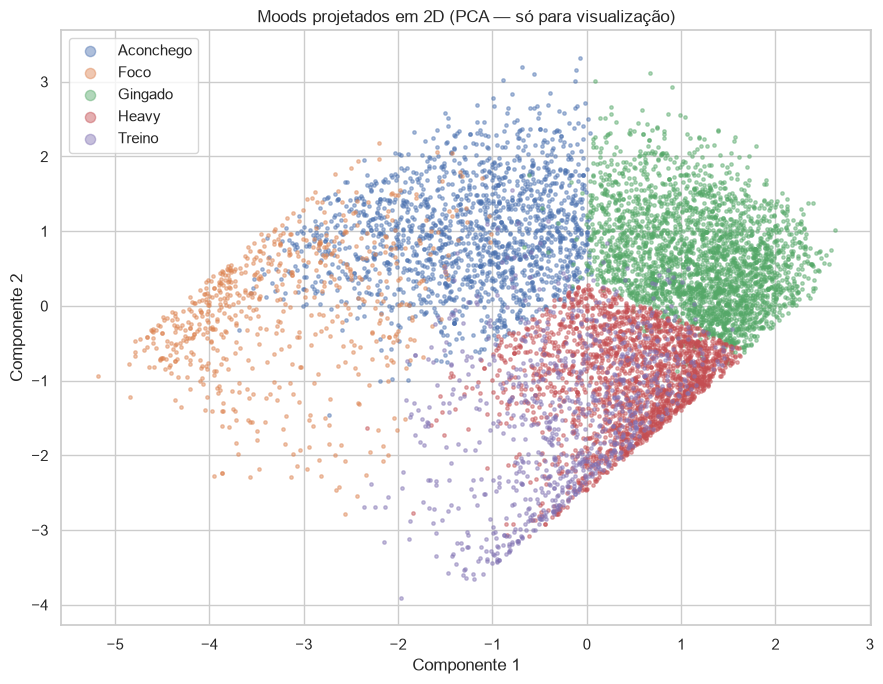

O PCA achata 6 dimensões em 2 e distorce distâncias — a clusterização
acontece nas 6 dimensões, não neste desenho.


In [37]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2).fit_transform(X_mood)   # X_mood = só o musical
moods_musical = faixas.loc[MUSICAL, "mood"].values     # alinhado com X_mood
idx = rng.choice(len(coords), 8000, replace=False)

fig, ax = plt.subplots(figsize=(9, 7))
for nome in sorted(pd.unique(moods_musical)):
    m = (moods_musical[idx] == nome)
    ax.scatter(coords[idx][m, 0], coords[idx][m, 1], s=6, alpha=.45, label=nome)
ax.set_title("Moods projetados em 2D (PCA — só para visualização)")
ax.set_xlabel("Componente 1"); ax.set_ylabel("Componente 2")
ax.legend(markerscale=3)
plt.tight_layout(); plt.show()
print("O PCA achata 6 dimensões em 2 e distorce distâncias — a clusterização")
print("acontece nas 6 dimensões, não neste desenho.")

## 8. Status do artista — Consolidado × Independente

O objetivo do produto é descobrir música parecida com o que você gosta **de
artistas pouco conhecidos**. Isso é uma propriedade do **artista**, não da
faixa — e a diferença entre as duas leituras é grande.

O campo `artists` pode conter vários artistas separados por `;`, então
explodimos antes de agregar.

In [38]:
expl = (faixas.reset_index()
        .assign(artista=lambda d: d["artists"].str.split(";"))
        .explode("artista"))
expl["artista"] = expl["artista"].str.strip()

artistas = expl.groupby("artista").agg(
    n_faixas=("track_id", "nunique"),
    pop_media=("popularity", "mean"),
    pop_max=("popularity", "max"),
).reset_index()

print(f"artistas distintos: {len(artistas):,}")
print(f"  com 1 faixa só: {(artistas.n_faixas == 1).sum():,} "
      f"({(artistas.n_faixas == 1).mean()*100:.1f}%)")

artistas distintos: 29,858
  com 1 faixa só: 15,007 (50.3%)


### A escolha da agregação muda tudo

"Agregação de métricas de catálogo" pode ser média ou máximo, e a diferença não
é sutil.

In [39]:
exemplos = ["Sam Smith", "David Guetta", "Bad Bunny", "Taylor Swift",
            "The Beatles", "Arctic Monkeys"]
print(f"{'artista':18} {'catálogo':>9} {'pop_media':>10} {'pop_MAX':>8}")
print("-" * 48)
for nome in exemplos:
    r = artistas[artistas.artista == nome]
    if len(r):
        r = r.iloc[0]
        print(f"{nome:18} {r.n_faixas:>9} {r.pop_media:>10.1f} {r.pop_max:>8}")

artista             catálogo  pop_media  pop_MAX
------------------------------------------------
Sam Smith                 47       13.6      100
David Guetta             105       31.1       98
Bad Bunny                129       39.6       97
Taylor Swift              15       52.1       88
The Beatles              150       60.3       82
Arctic Monkeys           110       60.1       92


**Pela média, Sam Smith é "independente".** Ele tem dezenas de faixas de álbum
obscuras que puxam a média para 13, embora "Unholy" esteja na popularidade 100.

Por isso usamos **`pop_max`**: um artista cuja melhor faixa é muito popular é
conhecido, não importa quantos lados-B tenha. A pergunta que queremos responder
é "alguém já ouviu esse artista?", e é `max` que responde.

In [40]:
TETO_ARTISTA = 50
artistas["status"] = np.where(artistas.pop_max >= TETO_ARTISTA,
                              "Consolidado", "Independente")
print(artistas["status"].value_counts().to_string())

mapa = dict(zip(artistas.artista, artistas.status))
expl["status"] = expl["artista"].map(mapa)
# a faixa só é independente se TODOS os seus artistas o forem
por_faixa = expl.groupby("track_id")["status"].apply(
    lambda s: "Independente" if (s == "Independente").all() else "Consolidado")
faixas["status_artista"] = por_faixa

faixas["elegivel"] = ((faixas.status_artista == "Independente")
                      & (faixas.popularity > PISO)
                      & faixas.e_musica)          # nada de stand-up na playlist
print(f"\nfaixas elegíveis (artista independente, popularity > {PISO}, música): "
      f"{faixas.elegivel.sum():,}")

status
Independente    19719
Consolidado     10139



faixas elegíveis (artista independente, popularity > 2, música): 35,899


=== corte por FAIXA vs corte por ARTISTA ===
  só por faixa   :   6,956  (popularidade média   9.9)
  só por artista :  35,899  (popularidade média  27.4)
  intersecção    :   4,884
  perdidas pelo corte por faixa: 31,015 faixas de artista desconhecido

as melhores faixas elegíveis — o produto em uma tela:
  pop= 49  Mone Kamishiraishi          なんでもないや - movie ver.
  pop= 49  Rachael Yamagata            "Something In the Rain" (Something I
  pop= 49  Lee DeWyze                  Blackbird Song
  pop= 49  Carly Lyman                 Landslide
  pop= 49  Dave Barnes                 God Gave Me You
  pop= 49  Joseph Sullinger            What a Wonderful World
  pop= 49  Manu Dibango                Soul Makossa
  pop= 49  Akalé Wubé                  Anbessa


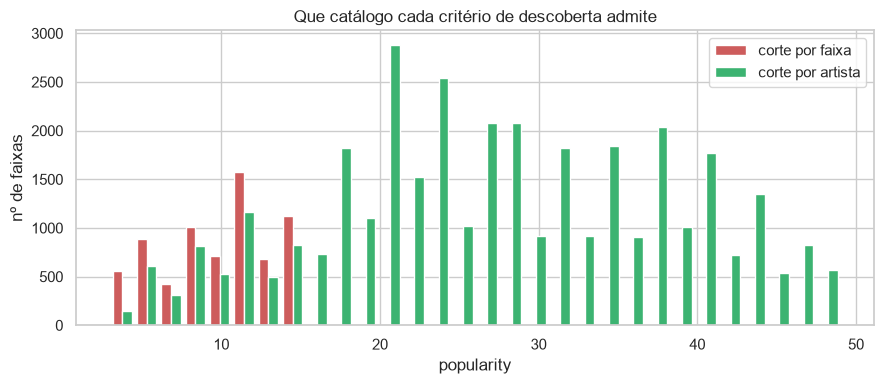

In [41]:
print("=== corte por FAIXA vs corte por ARTISTA ===")
A, B = faixas.faixa_obscura, faixas.elegivel
print(f"  só por faixa   : {A.sum():>7,}  (popularidade média {faixas[A].popularity.mean():5.1f})")
print(f"  só por artista : {B.sum():>7,}  (popularidade média {faixas[B].popularity.mean():5.1f})")
print(f"  intersecção    : {(A & B).sum():>7,}")
print(f"  perdidas pelo corte por faixa: {(B & ~A).sum():,} faixas de artista desconhecido")

print("\nas melhores faixas elegíveis — o produto em uma tela:")
for _, r in faixas[B].nlargest(8, "popularity").iterrows():
    a = str(r.artists).split(";")[0]
    print(f"  pop={r.popularity:>3}  {a[:26]:26}  {str(r.track_name)[:36]}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist([faixas[A].popularity, faixas[B].popularity], bins=30,
        label=["corte por faixa", "corte por artista"],
        color=["indianred", "mediumseagreen"])
ax.set_title("Que catálogo cada critério de descoberta admite")
ax.set_xlabel("popularity"); ax.set_ylabel("nº de faixas"); ax.legend()
plt.tight_layout(); plt.show()

=== reserva de joias por mood ===
           faixas_total  elegiveis   pct
mood                                    
Aconchego         18468       6566  35.6
Foco               6727       2673  39.7
Gingado           30238      11930  39.5
Heavy             23244       9018  38.8
Treino            10268       5712  55.6


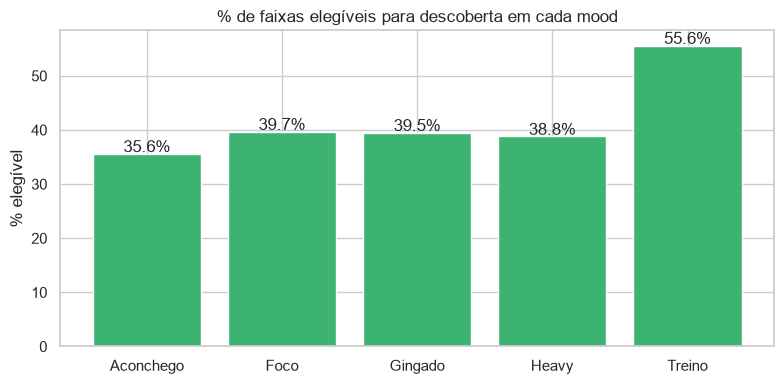

In [42]:
# Reserva de descobertas por mood: dá para recomendar em todas as vibes?
t = faixas.groupby("mood").agg(faixas_total=("popularity", "size"),
                               elegiveis=("elegivel", "sum"))
t["pct"] = (t.elegiveis / t.faixas_total * 100).round(1)
print("=== reserva de joias por mood ===")
print(t.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(t.index, t.pct, color="mediumseagreen")
for i, v in enumerate(t.pct):
    ax.text(i, v + .3, f"{v}%", ha="center")
ax.set_title("% de faixas elegíveis para descoberta em cada mood")
ax.set_ylabel("% elegível")
plt.tight_layout(); plt.show()

## 9. Motor de recomendação

Filtragem baseada em conteúdo com **similaridade de cosseno** sobre o vetor de
mood normalizado. Dado o que o usuário gosta, devolvemos faixas sonoramente
próximas **de artistas pouco conhecidos**.

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

# POS mapeia track_id -> linha de X_mood, que cobre só o catálogo musical.
POS = {tid: i for i, tid in enumerate(MUSICAL)}
CANDIDATAS = faixas.index[faixas.elegivel].to_numpy()
X_CAND = X_mood[[POS[t] for t in CANDIDATAS]]


def recomendar(track_ids, k=8, mood=None):
    """Joias escondidas parecidas com as faixas informadas."""
    validos = [t for t in track_ids if t in POS]
    if not validos:
        raise ValueError("nenhum track_id conhecido")

    perfil = X_mood[[POS[t] for t in validos]].mean(axis=0, keepdims=True)

    cand, xc = CANDIDATAS, X_CAND
    if mood is not None:
        m = faixas.loc[cand, "mood"].values == mood
        cand, xc = cand[m], xc[m]

    sim = cosine_similarity(perfil, xc)[0]
    fora = set(validos)
    ordem = [i for i in np.argsort(-sim) if cand[i] not in fora][:k]

    out = faixas.loc[cand[ordem], ["track_name", "artists", "popularity", "mood"]].copy()
    out["similaridade"] = sim[ordem].round(4)
    return out.reset_index()


# Demonstração: partindo de um hit conhecido
semente = faixas[faixas.popularity > 90].index[:1].tolist()
print("Semente:")
print(faixas.loc[semente, ["track_name", "artists", "popularity", "mood"]].to_string())
print("\nJoias escondidas recomendadas:")
print(recomendar(semente).to_string(index=False))

Semente:
                             track_name            artists  popularity   mood
track_id                                                                     
2QjOHCTQ1Jl3zawyYOpxh6  Sweater Weather  The Neighbourhood          93  Heavy

Joias escondidas recomendadas:
              track_id                                        track_name                            artists  popularity  mood  similaridade
42BrUYBLYMUtj8kx7hqjLU                                      Diante de Ti                      Quatro por Um          41 Heavy        0.9975
1urdP8pQZHZ8bBRBJIYu7C                                         Bad Dream                  Hands Like Houses          27 Heavy        0.9970
6HGm0lE0Oh7pdOVBFKdFLY                            Beväpna dig med vingar                           Thåström          35 Heavy        0.9964
4rOV8aTELyNKTyzA1juutO                                         Go fi dem Congo Natty;Izachar;Junior Baptist          16 Heavy        0.9955
2FT4seuDN3B78gusUndnxn Po

In [44]:
# A métrica que prova a correção do viés de popularidade
rec = recomendar(semente, k=50)
print(f"popularidade média das recomendações: {rec.popularity.mean():.1f}")
print(f"todas de artista independente: {faixas.loc[rec.track_id, 'status_artista'].eq('Independente').all()}")
print(f"popularidade média do catálogo  : {faixas.popularity.mean():.1f}")

popularidade média das recomendações: 29.0
todas de artista independente: True
popularidade média do catálogo  : 33.2


## 10. Exportação dos artefatos para o app

O `app.py` não deve recalcular nada: ele carrega os artefatos prontos. Guardar
o **mesmo `scaler`** é obrigatório — transformar as faixas do usuário com um
scaler novo compararia escalas diferentes.

In [45]:
import joblib

SAIDA = Path("../data/processed") if Path("../data").exists() else Path("data/processed")
SAIDA.mkdir(parents=True, exist_ok=True)

catalogo = faixas.reset_index()[[
    "track_id", "track_name", "artists", "album_name", "popularity",
    "generos", "n_generos", "mood", "cluster", "status_artista", "elegivel",
    *FEATURES_MOOD,
]].copy()
catalogo["generos"] = catalogo["generos"].apply(list)
catalogo.to_parquet(SAIDA / "catalogo.parquet", index=False)

joblib.dump({
    "scaler": scaler,
    "kmeans": kmeans,
    "features_mood": FEATURES_MOOD,
    "nomes_mood": {int(k): v for k, v in nomes.items()},
    "piso_popularidade": PISO,
    "teto_faixa_obscura": float(TETO),
    "teto_artista_consolidado": TETO_ARTISTA,
}, SAIDA / "modelo.joblib")

artistas.to_parquet(SAIDA / "artistas.parquet", index=False)

print(f"escrito em {SAIDA.resolve()}:")
for f in sorted(SAIDA.iterdir()):
    print(f"  {f.name:22} {f.stat().st_size/1_048_576:6.2f} MB")

escrito em C:\Users\Amanda\gems-finder-tic-ia2\data\processed:
  artistas.parquet         0.47 MB
  catalogo.parquet         5.95 MB
  modelo.joblib            0.34 MB


In [46]:
# Conferência: os artefatos voltam e reproduzem o resultado?
m = joblib.load(SAIDA / "modelo.joblib")
c = pd.read_parquet(SAIDA / "catalogo.parquet")
print(f"catálogo recarregado: {len(c):,} faixas")
print(f"features do modelo  : {m['features_mood']}")
print(f"moods               : {m['nomes_mood']}")
teste = m["scaler"].transform(faixas[FEATURES_MOOD].head(3))
print(f"scaler reaplicado   : ok, shape {teste.shape}")
print(f"elegíveis no parquet: {int(c.elegivel.sum()):,}")

catálogo recarregado: 89,740 faixas
features do modelo  : ['danceability', 'energy', 'valence', 'acousticness', 'instrumentalness']
moods               : {4: 'Foco', 2: 'Treino', 0: 'Gingado', 3: 'Heavy', 1: 'Aconchego'}
scaler reaplicado   : ok, shape (3, 5)
elegíveis no parquet: 35,899


## 11. O que ainda falta

- **Grafo de atributos e artistas** (nós de faixa, artista, gênero e vizinhança
  estrutural) — a busca por similaridade hoje é vetorial, sem grafo.
- **Avaliação offline da Precisão @8** com protocolo escrito. Enquanto não
  existir, `PRECISAO_8` em `src/dados.py` segue placeholder e a UI mantém a
  marca visível dizendo isso.
- **Reconciliar os moods com o protótipo.** `src/dados.py::VIBES` define Foco,
  Treino, Chill e Melancolia; os dados formaram Gingado, Fervo, Serenata e
  Foco. Só o **Foco** coincide. Decisão registrada: os dados mandam, e o
  protótipo será ajustado.
- **`explicit` na camada de gênero.** É o categórico mais informativo
  (V ≈ 0,40) e ainda não é usado em nada.
- **DJ sets contínuos no catálogo.** O teste de duração (§2.2) revelou 265
  faixas musicais com mais de 12 minutos — mixes de 70 a 87 min de
  minimal-techno e house. São música legítima, mas recomendar um mix contínuo
  de 87 minutos como "joia escondida" é estranho para o produto. Decidir se
  entram, e com que rótulo.
- **O `explicit` na entrega.** Nada no fluxo atual respeita conteúdo explícito,
  e o dataset marca isso.